# **TWITTER AIRLINE SENTIMENT ANALYSIS**

**Import data and Sanity Checks**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Tweets.csv")
print(df.shape)
df.head()

(14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
df = df[["text", "airline_sentiment", "airline"]]
print(df.shape)
df.head()

(14640, 3)


,text,airline_sentiment,airline
0,@VirginAmerica What @dhepburn said.,neutral,Virgin America
1,@VirginAmerica plus you've added commercials t...,positive,Virgin America
2,@VirginAmerica I didn't today... Must mean I n...,neutral,Virgin America
3,@VirginAmerica it's really aggressive to blast...,negative,Virgin America
4,@VirginAmerica and it's a really big bad thing...,negative,Virgin America


In [5]:
df["airline_sentiment"].value_counts()

,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


**Import NLP Libraries**

In [6]:
import re
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


**Clean the tweet text**

In [7]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join([w for w in text.split() if w not in stop_words])
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing


**Encode target labels**

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['airline_sentiment'])
print(le.classes_)  # shows mapping
print(df['sentiment'].value_counts())

['negative' 'neutral' 'positive']
sentiment
0    9178
1    3099
2    2363
Name: count, dtype: int64


## **TF-IDF Vectorization**

**Split features and target**

In [9]:
X = df['clean_text']
y = df['sentiment']

print("X shape:", X.shape)
print("y distribution:", y.value_counts())

X shape: (14640,)
y distribution: sentiment
0    9178
1    3099
2    2363
Name: count, dtype: int64


**Train/Test split**

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (11712,)
Test size: (2928,)


**TF-IDF Vectorization**

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf  = tfidf.transform(X_test)

print("TF-IDF matrix shape:", X_train_tf.shape)

TF-IDF matrix shape: (11712, 5000)


## **Handle Imbalance & Train Models**

**Handle imbalance with SMOTE**

In [12]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train_tf, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 7343, 1: 2479, 2: 1890}
After SMOTE: {1: 7343, 0: 7343, 2: 7343}


**Train Logistic Regression**

In [13]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_sm, y_train_sm)
print("✅ Logistic Regression trained")

✅ Logistic Regression trained


**Train Naive Bayes**

In [14]:
from sklearn.naive_bayes import MultinomialNB
from imblearn.over_sampling import SMOTE

# Naive Bayes needs non-negative values — use original data
nb = MultinomialNB()
nb.fit(X_train_tf, y_train)
print("✅ Naive Bayes trained")

✅ Naive Bayes trained


## **Evaluation**

**Predictions**

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Logistic Regression
lr_preds = lr.predict(X_test_tf)

# Naive Bayes
nb_preds = nb.predict(X_test_tf)

**Classification Reports**

In [16]:
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds,
      target_names=['Negative', 'Neutral', 'Positive']))

print("=== Naive Bayes ===")
print(classification_report(y_test, nb_preds,
      target_names=['Negative', 'Neutral', 'Positive']))

=== Logistic Regression ===
              precision    recall  f1-score   support

    Negative       0.88      0.83      0.85      1835
     Neutral       0.56      0.62      0.59       620
    Positive       0.64      0.68      0.66       473

    accuracy                           0.76      2928
   macro avg       0.69      0.71      0.70      2928
weighted avg       0.77      0.76      0.76      2928

=== Naive Bayes ===
              precision    recall  f1-score   support

    Negative       0.73      0.98      0.84      1835
     Neutral       0.69      0.25      0.37       620
    Positive       0.86      0.42      0.56       473

    accuracy                           0.74      2928
   macro avg       0.76      0.55      0.59      2928
weighted avg       0.74      0.74      0.69      2928



**Confusion Matrix**

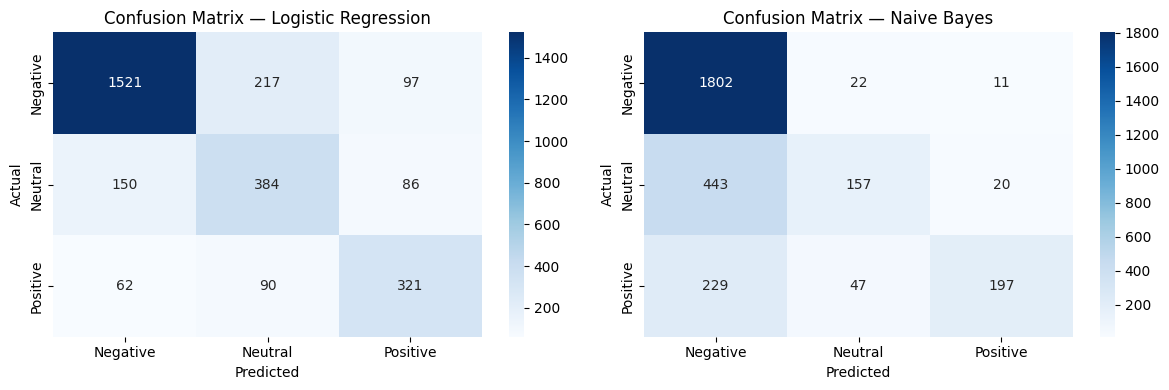

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, name in zip(axes,
                            [lr_preds, nb_preds],
                            ["Logistic Regression", "Naive Bayes"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

**F1 Scores**

In [18]:
from sklearn.metrics import f1_score

lr_f1 = f1_score(y_test, lr_preds, average='weighted')
nb_f1 = f1_score(y_test, nb_preds, average='weighted')

print(f"Logistic Regression F1: {lr_f1:.4f}")
print(f"Naive Bayes F1:         {nb_f1:.4f}")

if lr_f1 > nb_f1:
    print("\n🏆 Best Model: Logistic Regression")
else:
    print("\n🏆 Best Model: Naive Bayes")

Logistic Regression F1: 0.7645
Naive Bayes F1:         0.6936

🏆 Best Model: Logistic Regression


## **EDA Visualizations**

**Sentiment Distribution**

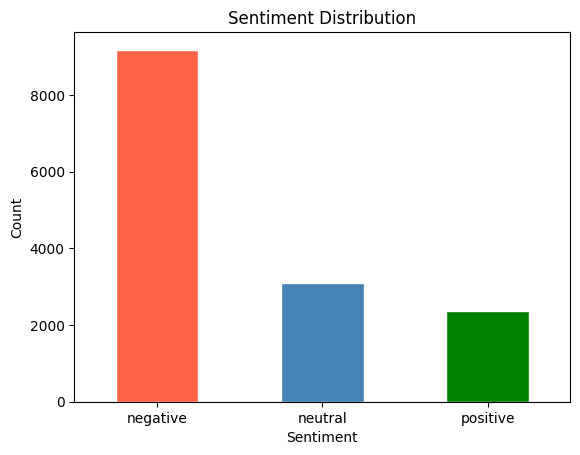

In [19]:
df['airline_sentiment'].value_counts().plot(
    kind='bar', color=['tomato', 'steelblue', 'green'], edgecolor='white')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

**Sentiment by Airline**

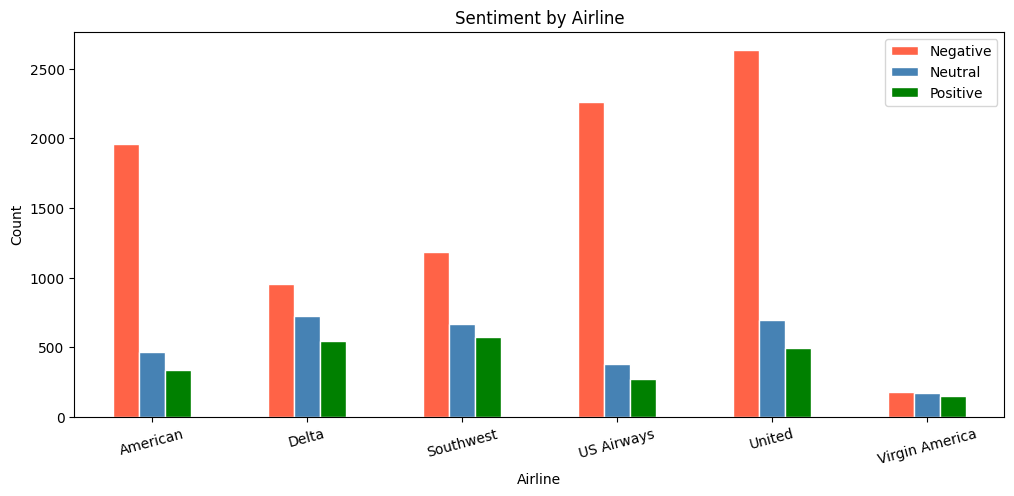

In [20]:
airline_sentiment = df.groupby(['airline', 'airline_sentiment']).size().unstack()
airline_sentiment.plot(kind='bar', figsize=(12, 5),
                       color=['tomato', 'steelblue', 'green'],
                       edgecolor='white')
plt.title("Sentiment by Airline")
plt.xlabel("Airline")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.legend(['Negative', 'Neutral', 'Positive'])
plt.show()

**Word Cloud for Negative tweets**

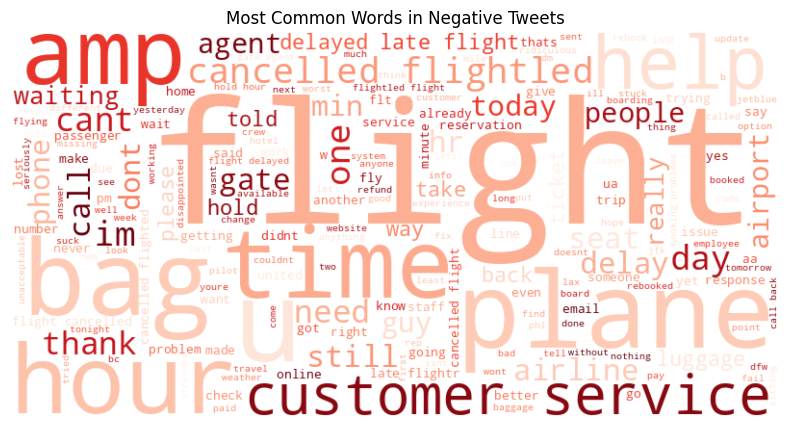

In [21]:
!pip install wordcloud -q
from wordcloud import WordCloud

negative_text = ' '.join(df[df['airline_sentiment'] == 'negative']['clean_text'])
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='Reds').generate(negative_text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Negative Tweets")
plt.show()

**Word Cloud for Positive tweets**

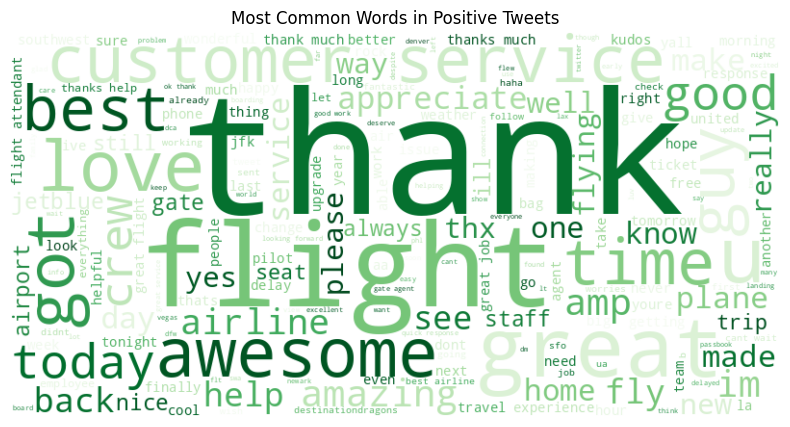

In [22]:
positive_text = ' '.join(df[df['airline_sentiment'] == 'positive']['clean_text'])
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='Greens').generate(positive_text)

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words in Positive Tweets")
plt.show()

##**Business Insights**

**Key Findings**

- 63% of tweets are negative — majority of customers are unhappy
- Only 16% of tweets are positive — very low customer satisfaction
- Neutral tweets at 21% suggest many customers are indifferent
- Class imbalance reflects real world — unhappy customers tweet more

**Airline Insights**

- United and American Airlines receive the most negative tweets
- Virgin America has the highest proportion of positive sentiment
- Southwest performs better than average on customer satisfaction
- All airlines struggle with neutral-to-positive conversion


**Model Results**

- Logistic Regression outperformed Naive Bayes (F1: 0.76 vs 0.69)
- Negative sentiment predicted most accurately — largest class
- Neutral tweets hardest to classify — often confused with negative
- TF-IDF with bigrams captured phrases like "flight delayed" effectively

**Recommendations**

- United and American Airlines need urgent customer service improvement
- Focus on reducing flight delays — most common negative trigger
- Replicate Virgin America's service model across other airlines
- Monitor real-time tweet sentiment to catch issues early
- Target neutral customers with proactive engagement to convert them positive